In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sci

folderpath="data-2026-04-30-15-00-36"
flukepath = f'{folderpath}/FLUKE_data.csv'
stmpath = f'{folderpath}/STM_data.csv'

#reading the fluke shit
def read_fluke(filepath=flukepath):
    try:
        return pd.read_csv(filepath, names=["Time", "Pressure", "Unit"])
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return None
    except TypeError:
        with open(filepath, 'r') as file:
            for line in file:
                print(line.strip())
                
#dFL = read_fluke(filepath=f"{flukepath}").dropna()
#dFLf = read_fluke(filepath=f"{flukepath}.fixed").dropna()

In [2]:
# we need to fix fluke_data, it has rows which dont have three columns...
def fix_fluke_data(filepath=flukepath, overwrite=False):
    if overwrite:
        with open(filepath, 'r') as file:
            lines = file.readlines()
    
        fixed_lines = []
        for line in lines:
            parts = line.strip().split(',')
            if len(parts) == 3:
                fixed_lines.append(line)
            else:
                print(f"Skipping malformed line: {line.strip()}")

        F = len(lines)
        f = len(fixed_lines)
        with open(filepath, 'w') as file:
            file.writelines(fixed_lines)
            if f == F:
                print("No malformed lines found. No changes made.")
            else:
                print(f"Fixed data written (n = {f}, dn = {F-f}) back to '{filepath}' succesfully.")
    else:
        f = 0
        F = 0
        with open(filepath, 'r') as file:
            with open(f'{filepath}.fixed', 'w') as fixed_file:
                for line in file:
                    F += 1
                    parts = line.strip().split(',')
                    if len(parts) == 3:
                        fixed_file.write(line)
                        f += 1
                    else:
                        print(f"Skipping malformed line: {line.strip()}")
        print(f"Fixed data written (n = {f}, dn = {F-f}) to '{filepath}.fixed' successfully.")

#fix_fluke_data()

In [3]:
# stm stuff

def _stm_adc_convert(short_hex):
    # Format: XXXXXX string.
    # Conversion table: 0x000000 = 0, 0x7FFFFF = 1, 0x800000 = -1, 0xFFFFFF = -2.
    if len(short_hex) != 6:
        return None
    try:
        int_value = int(short_hex, 16)
        if int_value >= 0x800000:
            return int_value - 0x1000000
        else:
            return int_value
    except ValueError:
        return None

def _stm_convert_hex_to_list(hex_string):
    # six parts to the hex string: AA, BB, CC, DD, EE, FF. AA, BB and CC will be appended separately, DD-FF is the data and should be converted.
    if len(hex_string) != 12:
        return None
    try:
        AA = hex_string[0:2]
        BB = hex_string[2:4]
        CC = hex_string[4:6]
        data_hex = hex_string[6:12]
        data_int = _stm_adc_convert(data_hex)
        return [AA, BB, CC, data_int]
    except ValueError:
        return None

def read_stm(filepath=stmpath):
    outputdict = {} # structure: {signature: list((timestamp, status, value), (timestamp, status, value))...}
    with open(filepath, 'r') as file:
        data = []
        for line_number, line in enumerate(file):
            parts = line.strip("\r\n").split(',')
            if len(parts) == 3:
                timestamp, status, value = parts
                try:
                    signature, output = [x.strip() for x in value.split(":")]
                    if signature not in outputdict.keys():
                        outputdict[signature] = []
                    else:
                        convert_output = _stm_convert_hex_to_list(output)
                        outputdict[signature].append((float(timestamp), *convert_output))
                except ValueError:
                    #print(f"Skipping malformed value at line {line_number + 1}: {value}")
                    continue
            #else:
                #print(f"Skipping malformed line at line {line_number + 1}: {line.strip()}")
    for signature, data in outputdict.items():
        print(f"Signature: {signature}, Number of entries: {len(data)}")
        if len(data[0]) == 5:
            outputdict[signature] = pd.DataFrame(data, columns=["Timestamp", "High", "Echo", "Status", "Data"])
        else:
            outputdict[signature] = pd.DataFrame(data, columns=["Timestamp", "Status"])
    return outputdict

In [4]:
hmmm = read_stm()

Signature: V, Number of entries: 442
Signature: T2, Number of entries: 441
Signature: T3, Number of entries: 441
Signature: T4, Number of entries: 441
Signature: T5, Number of entries: 441
Signature: T6, Number of entries: 441


In [5]:
T6d = hmmm["T6"]

In [6]:
def integer_to_temperature(integer_value):
    #
    # integer was represented by a HEX, which has LSB at 0x000000, PFS at 0x7FFFFF, and NSF at 0x800000, and -1 LSB at 0xFFFFFF.
    
    # Normalize to (-1,1):
    ratio = integer_value / 0x7FFFFF
    resistance = ratio * 2000 # 2k reference
    temp = -((-0.00232*resistance + 17.59246)**0.5 - 3.908) / 0.00116
    return temp

def integer_to_voltage(integer_value):
    # integer was represented by a HEX, which has LSB at 0x000000, PFS at 0x7FFFFF, and NSF at 0x800000, and -1 LSB at 0xFFFFFF.
    
    # Normalize to (-1,1):
    ratio = integer_value / 0x7FFFFF
    voltage = ratio * 5 # 5V reference
    return voltage

In [7]:
fig, axes = plt.subplots(5, 1, sharex=True)
for i, tsensor in enumerate(["T2", "T3", "T4", "T5", "T6"]):
    fuckmyassholedaddy = hmmm[tsensor]
    ploty = fuckmyassholedaddy["Data"] 
    # remove outliers
    ploty = integer_to_temperature(ploty)
    #ploty = ploty[(ploty > 0) & (ploty < 50)]
    plotx = fuckmyassholedaddy["Timestamp"][ploty.index]
    axes[i].plot(plotx, ploty, label=f"{tsensor}")
    axes[i].legend()
    #axes[i].set_ylim(0, 50)

Error in callback <function flush_figures at 0x000001FEB606FC40> (for post_execute):


KeyboardInterrupt: 

In [ ]:

T3c = integer_to_temperature(hmmm["T3"]["Data"])
T3mask = (T3c > 0) & (T3c < 50)
T3m = T3c[T3mask]
T3mx = hmmm["T3"]["Timestamp"][T3mask]

T2c = integer_to_temperature(hmmm["T2"]["Data"])
T2mask = (T2c > 0) & (T2c < 50)
T2m = T2c[T2mask]
T2mx = hmmm["T2"]["Timestamp"][T2mask]

Pm = dFLf["Pressure"]
Pmask = (Pm > 0) & (Pm < 75)
Pm = Pm[Pmask]
Pmx = dFLf["Time"][Pmask]

Vc = integer_to_voltage(hmmm["V"]["Data"]) * 1000 * 2
Vmask = (Vc > -200) & (Vc < 200)
Vm = Vc[Vmask]
Vmx = hmmm["V"]["Timestamp"][Vmask]

NameError: name 'dFLf' is not defined

In [ ]:
tseries = np.linspace(np.min([T3mx.min(), T2mx.min(), Pmx.min(), Vmx.min()]), np.max([T3mx.max(), T2mx.max(), Pmx.max(), Vmx.max()]), 1000)
T3i, T2i, Pi, Vi = [np.interp(tseries, Yx, Y) for Yx, Y in [(T3mx, T3m), (T2mx, T2m), (Pmx, Pm), (Vmx, Vm)]]
Ti = np.mean((T3i, T2i), axis=0)

NameError: name 'Pmx' is not defined

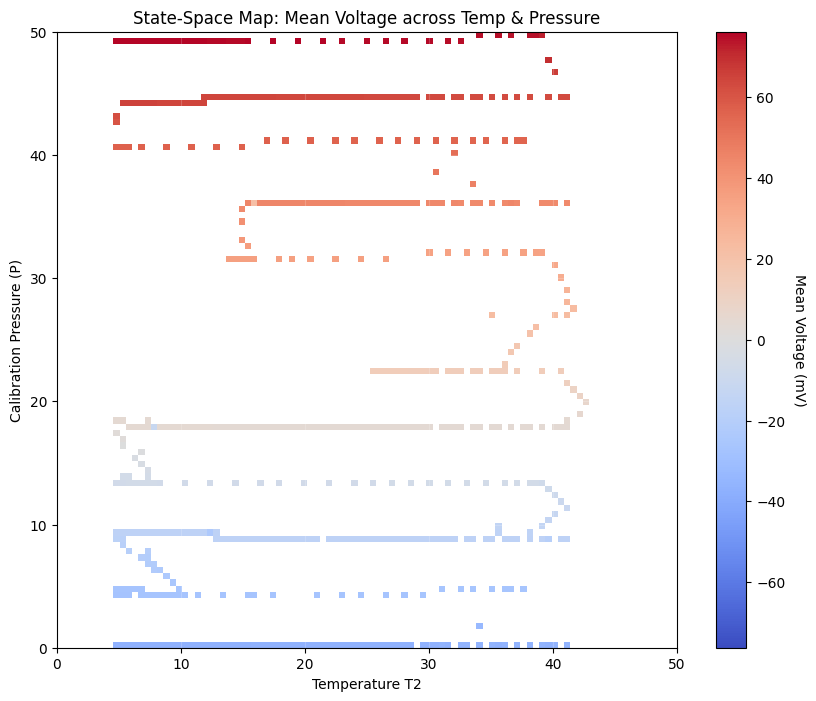

In [ ]:
import matplotlib.colors as colors
temp_bins = np.linspace(0, 50, 100)  
press_bins = np.linspace(0, 50, 100)

heatmap = sci.stats.binned_statistic_2d(
    x=Ti, 
    y=Pi, 
    values=Vi, 
    statistic='mean', 
    bins=[temp_bins, press_bins]
)
Z_mean = heatmap.statistic

plt.figure(figsize=(10, 8))
X, Y = np.meshgrid(heatmap.x_edge, heatmap.y_edge)
mesh = plt.pcolormesh(X, Y, Z_mean.T, cmap='coolwarm', shading='flat', norm=colors.CenteredNorm())
cbar = plt.colorbar(mesh)
cbar.set_label('Mean Voltage (mV)', rotation=270, labelpad=15)
plt.xlabel('Temperature T2')
plt.ylabel('Calibration Pressure (P)')
plt.title('State-Space Map: Mean Voltage across Temp & Pressure')
plt.xlim(0, 50)
plt.ylim(0, 50)
plt.grid(True, color='white', linestyle='-', alpha=0.2)
plt.show()